In [6]:
import numpy as np

In [7]:
import pandas as pd

geneinfo = pd.read_csv(
    "geneinfo_beta.txt",
    sep="\t"
)

geneinfo.to_csv(
    "geneinfo_beta.csv",
    index=False
)

print("geneinfo columns:")
print(geneinfo.columns.tolist())
print("rows:", geneinfo.shape)

geneinfo columns:
['gene_id', 'gene_symbol', 'ensembl_id', 'gene_title', 'gene_type', 'src', 'feature_space']
rows: (12328, 7)


In [9]:

siginfo = pd.read_csv(
    "siginfo_beta.txt",
    sep="\t"
)

siginfo.to_csv(
    "siginfo_beta.csv",
    index=False
)

print("siginfo columns:")
print(siginfo.columns.tolist())
print("rows:", siginfo.shape)

C:\Users\ramru\AppData\Local\Temp\ipykernel_6368\615098406.py:1: DtypeWarning: Columns (0,3,4,28,29) have mixed types. Specify dtype option on import or set low_memory=False.
  siginfo = pd.read_csv(


siginfo columns:
['bead_batch', 'nearest_dose', 'pert_dose', 'pert_dose_unit', 'pert_idose', 'pert_itime', 'pert_time', 'pert_time_unit', 'cell_mfc_name', 'pert_mfc_id', 'nsample', 'cc_q75', 'ss_ngene', 'tas', 'pct_self_rank_q25', 'wt', 'median_recall_rank_spearman', 'median_recall_rank_wtcs_50', 'median_recall_score_spearman', 'median_recall_score_wtcs_50', 'batch_effect_tstat', 'batch_effect_tstat_pct', 'is_hiq', 'qc_pass', 'pert_id', 'sig_id', 'pert_type', 'cell_iname', 'det_wells', 'det_plates', 'distil_ids', 'build_name', 'project_code', 'cmap_name', 'is_exemplar_sig', 'is_ncs_sig', 'is_null_sig']
rows: (1201944, 37)


In [10]:
# load
geneinfo = pd.read_csv("geneinfo_beta.csv")

# keep landmark genes only
landmark = geneinfo[geneinfo["feature_space"] == "landmark"]

# sanity
print("Landmark genes:", landmark.shape[0])

# save IDs for slicing
landmark_ids = landmark["gene_id"].tolist()

pd.Series(landmark_ids).to_csv(
    "landmark_gene_ids.csv",
    index=False,
    header=False
)


Landmark genes: 978


In [11]:
siginfo = pd.read_csv("siginfo_beta.csv", low_memory=False)

# keep compounds only
sig_cp = siginfo[siginfo["pert_type"] == "trt_cp"].copy()

# normalize LINCS drug names
sig_cp["drug_name_norm"] = sig_cp["cmap_name"].str.lower()


In [12]:
# load sider–lincs common drugs
common = pd.read_csv("sider_lincs_common_clean_FINAL.csv")

print(common.columns)
print("Total common drugs:", common.shape[0])


Index(['drug_id', 'drug_cid', 'drug_name', 'sider_norm_name', 'pert_id',
       'pert_iname', 'adr_id', 'adr_name'],
      dtype='object')
Total common drugs: 137270


In [13]:
common_drugs = set(common["drug_name"].str.lower())

sig_sel = sig_cp[sig_cp["drug_name_norm"].isin(common_drugs)]

print("Selected signatures:", sig_sel.shape[0])
print("Unique drugs:", sig_sel["drug_name_norm"].nunique())


Selected signatures: 129236
Unique drugs: 679


In [15]:
# unique sig_ids for GCTX slicing
sig_ids = sig_sel["sig_id"].unique()

pd.Series(sig_ids).to_csv(
    "selected_sig_ids_sider_lincs.csv",
    index=False,
    header=False
)

# keep full metadata for aggregation later
sig_sel.to_csv(
    "selected_siginfo_sider_lincs.csv",
    index=False
)


In [17]:
# landmark genes
landmark_gene_ids = pd.read_csv(
    "landmark_gene_ids.csv",
    header=None
)[0].astype(str).tolist()

print("Landmark genes:", len(landmark_gene_ids))

# selected signatures
sig_ids = pd.read_csv(
    "selected_sig_ids_sider_lincs.csv",
    header=None
)[0].astype(str).tolist()

print("Selected sig_ids:", len(sig_ids))


Landmark genes: 978
Selected sig_ids: 129236


In [18]:
from cmapPy.pandasGEXpress.parse import parse

gctx_path = "C:/Users/ramru/Downloads/level5_beta_trt_cp_n720216x12328.gctx"

# slice
gctoo = parse(
    gctx_path,
    cid=sig_ids,          # columns
    rid=landmark_gene_ids # rows
)

print("Sliced matrix shape:", gctoo.data_df.shape)


C:\Users\ramru\AppData\Local\Programs\Python\Python311\Lib\site-packages\cmapPy\pandasGEXpress\parse_gctx.py:275: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  meta_df = meta_df.apply(lambda x: pd.to_numeric(x, errors="ignore"))
C:\Users\ramru\AppData\Local\Programs\Python\Python311\Lib\site-packages\cmapPy\pandasGEXpress\parse_gctx.py:275: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  meta_df = meta_df.apply(lambda x: pd.to_numeric(x, errors="ignore"))


Sliced matrix shape: (978, 129236)


In [19]:
from cmapPy.pandasGEXpress.parse import parse

In [20]:
gctoo.data_df.to_pickle("level5_landmark_slice.pkl")

In [21]:
# load sliced expression matrix
X = pd.read_pickle("level5_landmark_slice.pkl")
# rows: gene_id, columns: sig_id

print("Slice shape:", X.shape)


Slice shape: (978, 129236)


In [22]:
# load signature metadata
siginfo = pd.read_csv("selected_siginfo_sider_lincs.csv")

# normalize drug names (again, to be safe)
siginfo["drug_name_norm"] = siginfo["cmap_name"].str.lower()

In [23]:
# keep only sigs present in the slice
siginfo = siginfo[siginfo["sig_id"].isin(X.columns)]

# reorder siginfo to match X column order
siginfo = siginfo.set_index("sig_id").loc[X.columns].reset_index()

In [24]:
# transpose so each row = one signature
Xt = X.T

# attach drug label to each signature
Xt["drug"] = siginfo["drug_name_norm"].values


In [25]:
# Median effect (μ)
Gdrug_mu = Xt.groupby("drug").median().T

# Variability (σ = MAD)
# Gdrug_sigma = Xt.groupby("drug").mad().T


In [26]:
print(Gdrug_mu.shape)   
print((Gdrug_mu != 0).sum().mean())  # ≈ K
print(Gdrug_mu.values.min(), Gdrug_mu.values.max())
# print(Gdrug_sigma.values.min(), Gdrug_sigma.values.max()) 

(978, 679)
964.5861561119293
-10.0 10.0


In [27]:
# ---- μ: median perturbation ----
Gdrug_mu = Xt.groupby("drug").median().T

In [28]:
# ---- σ: MAD (robust variability) ----
def mad(df):
    med = df.median()
    return (df - med).abs().median()

Gdrug_sigma = Xt.groupby("drug").apply(mad).T

In [29]:
# SPARSIFY BY |μ|

K = 300  # genes per drug

mask = Gdrug_mu.abs().apply(
    lambda col: col.rank(ascending=False, method="first") <= K,
    axis=0
)

Gdrug_mu = Gdrug_mu.where(mask, 0)
Gdrug_sigma = Gdrug_sigma.where(mask, 0)

In [30]:
Gdrug_mu = Gdrug_mu.where(mask, 0)
Gdrug_sigma = Gdrug_sigma.where(mask, 0)

In [31]:
print("Gdrug_mu shape:", Gdrug_mu.shape)
print("Gdrug_sigma shape:", Gdrug_sigma.shape)

print("Avg nonzeros per drug:",(Gdrug_mu != 0).sum().mean())

print("μ range:",Gdrug_mu.values.min(), Gdrug_mu.values.max())

print("σ min:",Gdrug_sigma.min().min())
print("σ max:",Gdrug_sigma.max().max())



Gdrug_mu shape: (978, 679)
Gdrug_sigma shape: (978, 679)
Avg nonzeros per drug: 300.0
μ range: -10.0 10.0
σ min: 0.0
σ max: 5.1759


In [32]:
Gdrug_mu.to_pickle("Gdrug_mu.pkl")
Gdrug_sigma.to_pickle("Gdrug_sigma.pkl")

In [34]:
gene_info = pd.read_csv("geneinfo_beta.csv")
entrez_ids = (
    pd.Series(X.index, name="gene_id")
    .astype(str)
)

gene_info["gene_id"] = gene_info["gene_id"].astype(str)

gene_index_lincs = (
    entrez_ids
    .to_frame()
    .merge(
        gene_info[["gene_id", "gene_symbol"]],
        on="gene_id",
        how="left"
    )
)


In [35]:
gene_index_lincs.isna().sum()

gene_id        0
gene_symbol    0
dtype: int64

In [36]:
gene_index_lincs["GeneSymbol"] = (
    gene_index_lincs["gene_symbol"]
    .astype(str)
    .str.upper()
    .str.strip()
)

# gene_index_lincs = gene_index_lincs.reset_index(drop=True)
# gene_index_lincs["gene_idx"] = gene_index_lincs.index

gene_index_lincs = gene_index_lincs[["gene_id", "GeneSymbol"]]

gene_index_lincs.to_csv("gene_index_lincs.csv", index=False)


In [37]:
gene_index_lincs.head()

,gene_id,GeneSymbol
0,10007,GNPDA1
1,1001,CDH3
2,10013,HDAC6
3,10038,PARP2
4,10046,MAMLD1


In [38]:
print("μ mean:", Gdrug_mu.values.mean())
print("μ median:", np.median(Gdrug_mu.values))

μ mean: 0.0018987487
μ median: 0.0


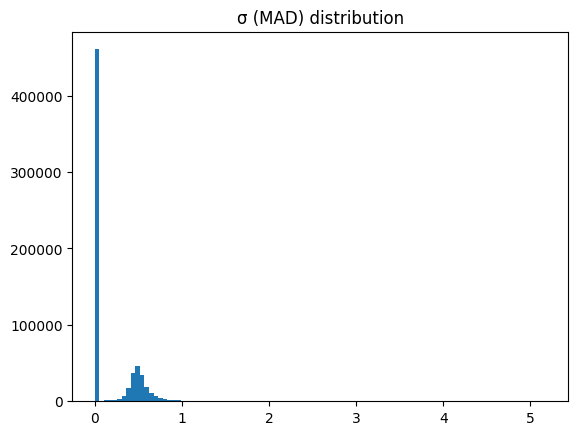

In [39]:
import matplotlib.pyplot as plt

plt.hist(Gdrug_sigma.values.flatten(), bins=100)
plt.title("σ (MAD) distribution")
plt.show()


In [45]:
energy = Gdrug_mu.abs().sum(axis=0)
energy.describe()

count     679.000000
mean      102.213318
std        80.645546
min        39.418457
25%        59.494629
50%        76.745110
75%       114.885696
max      1260.546509
dtype: float64

In [46]:
gene_hit_count = (Gdrug_mu != 0).sum(axis=1)
gene_hit_count.describe()

count    978.000000
mean     208.282209
std       50.576898
min        3.000000
25%      174.000000
50%      202.500000
75%      239.000000
max      372.000000
dtype: float64

In [48]:
import numpy as np

mu_vals = Gdrug_mu.abs().values.flatten()
sigma_vals = Gdrug_sigma.values.flatten()

valid = mu_vals > 0
np.corrcoef(mu_vals[valid], sigma_vals[valid])[0,1]


np.float64(0.5701184081786836)

In [49]:
from sklearn.metrics.pairwise import cosine_similarity

cosine_similarity(
    Gdrug_mu[["atorvastatin", "simvastatin"]].T
)


array([[1.0000001, 0.6213964],
       [0.6213964, 1.       ]], dtype=float32)

In [50]:
(Gdrug_mu != 0).sum().mean()

np.float64(300.0)

In [ ]:
drug_index = (
    pd.DataFrame({"drug_id": Gdrug_mu.columns})
    .reset_index(drop=True)
)

drug_index["drug_idx"] = drug_index.index
drug_index = drug_index[["drug_idx", "drug_id"]]

drug_index.to_csv("drug_index.csv", index=False)

In [74]:
assert Gdrug_mu.shape[1] == len(drug_index)